## Oscillator 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator


import os
import json

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
# pip install SciencePlots

import scienceplots
import numpy as np
from scipy.stats import gaussian_kde
from adjustText import adjust_text

from dataclasses import dataclass, field
plt.style.use('science')

carbon = {
  "black": { "100": "#000000" },
  "white": { "0": "#ffffff" },
  "blue": { "10": "#edf5ff", "20": "#d0e2ff", "30": "#a6c8ff", "40": "#78a9ff", "50": "#4589ff", "60": "#0f62fe", "70": "#0043ce", "80": "#002d9c", "90": "#001d6c", "100": "#001141" },
  "coolGray": { "10": "#f2f4f8", "20": "#dde1e6", "30": "#c1c7cd", "40": "#a2a9b0", "50": "#878d96", "60": "#697077", "70": "#4d5358", "80": "#343a3f", "90": "#21272a", "100": "#121619" },
  "cyan": { "10": "#e5f6ff", "20": "#bae6ff", "30": "#82cfff", "40": "#33b1ff", "50": "#1192e8", "60": "#0072c3", "70": "#00539a", "80": "#003a6d", "90": "#012749", "100": "#061727" },
  "gray": { "10": "#f4f4f4", "20": "#e0e0e0", "30": "#c6c6c6", "40": "#a8a8a8", "50": "#8d8d8d", "60": "#6f6f6f", "70": "#525252", "80": "#393939", "90": "#262626", "100": "#161616" },
  "green": { "10": "#defbe6", "20": "#a7f0ba", "30": "#6fdc8c", "40": "#42be65", "50": "#24a148", "60": "#198038", "70": "#0e6027", "80": "#044317", "90": "#022d0d", "100": "#071908" },
  "magenta": { "10": "#fff0f7", "20": "#ffd6e8", "30": "#ffafd2", "40": "#ff7eb6", "50": "#ee5396", "60": "#d02670", "70": "#9f1853", "80": "#740937", "90": "#510224", "100": "#2a0a18" },
  "orange": { "10": "#fff2e8", "20": "#ffd9be", "30": "#ffb784", "40": "#ff832b", "50": "#eb6200", "60": "#ba4e00", "70": "#8a3800", "80": "#5e2900", "90": "#3e1a00", "100": "#231000" },
  "purple": { "10": "#f6f2ff", "20": "#e8daff", "30": "#d4bbff", "40": "#be95ff", "50": "#a56eff", "60": "#8a3ffc", "70": "#6929c4", "80": "#491d8b", "90": "#31135e", "100": "#1c0f30" },
  "red": { "10": "#fff1f1", "20": "#ffd7d9", "30": "#ffb3b8", "40": "#ff8389", "50": "#fa4d56", "60": "#da1e28", "70": "#a2191f", "80": "#750e13", "90": "#520408", "100": "#2d0709" },
  "teal": { "10": "#d9fbfb", "20": "#9ef0f0", "30": "#3ddbd9", "40": "#08bdba", "50": "#009d9a", "60": "#007d79", "70": "#005d5d", "80": "#004144", "90": "#022b30", "100": "#081a1c" },
  "warmGray": { "10": "#f7f3f2", "20": "#e5e0df", "30": "#cac5c4", "40": "#ada8a8", "50": "#8f8b8b", "60": "#726e6e", "70": "#565151", "80": "#3c3838", "90": "#272525", "100": "#171414" },
  "yellow": { "10": "#fcf4d6", "20": "#fddc69", "30": "#f1c21b", "40": "#d2a106", "50": "#b28600", "60": "#8e6a00", "70": "#684e00", "80": "#483700", "90": "#302400", "100": "#1c1500" },
  "rose": { "10": "#fcf2ed", "20": "#f9d9d1", "30": "#f0b8a7", "40": "#e99179", "50": "#d37258", "60": "#ab5638", "70": "#853c27", "80": "#622517", "90": "#46170c", "100": "#2a0d09" },
  "almond": { "10": "#f8f3ea", "20": "#efdcc8", "30": "#e1bd9f", "40": "#d1a080", "50": "#b88361", "60": "#97633f", "70": "#76472b", "80": "#55301e", "90": "#3a1e12", "100": "#27120a" }
}
matplotlib.style.use({
    'axes.edgecolor': carbon['gray']['90'],
    'xtick.color': carbon['gray']['90'],
    'ytick.color': carbon['gray']['90'],
    'axes.labelcolor': carbon['gray']['90'],
    'axes.titlecolor': carbon['gray']['90'],
})



### Qwen-0.5B

0 0.0020535036321787845
1 0.0022578616001351784
2 0.003234122088762386
3 0.0020028515104559452


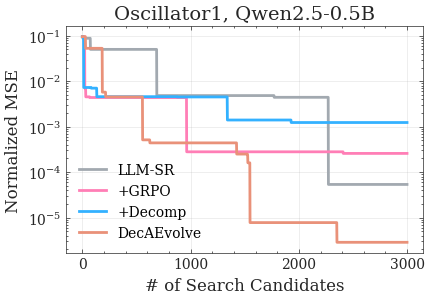

In [9]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "oscillator1_llmsr_Qwen2.5-0.5B-Instruct",
    "oscillator1_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp50",
    "oscillator1_llmsr_dec_Qwen2.5-0.5B-Instruct",
    "oscillator1_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp50_v2",
]


# modified
# log_ids = [
#     "oscillator1_llmsr_Qwen2.5-0.5B-Instruct",
#     "oscillator1_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp50",
#     "oscillator1_llmsr_dec_Qwen2.5-0.5B-Instruct",
#     "oscillator1_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp50_v2",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))


import pandas as pd
data_path = f'./data/oscillator1/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)


matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        # if i == 0:
        #     plt.plot(x_axis, nmse+0.002, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        #     print(i,nmse[-1]+0.002)

        # elif i == 3:
        #     # Find the last index of nmse and fill the remaining indices until 3000 with the last value
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        #     print(i,nmse[-1])
            
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1]+0.002)

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("Oscillator1, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2000)
plt.xticks(np.arange(0, 3001, 1000))




# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_oscillator1-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen-1.5B

0 1.8955334870212296e-05
1 1.476429221349961e-10
2 1.4729477591218343e-11
3 8.69622652861603e-07


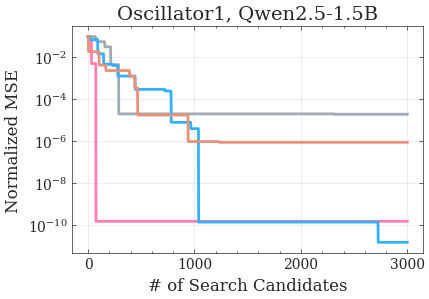

In [10]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "oscillator1_llmsr_Qwen2.5-1.5B-Instruct",
    "oscillator1_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
    "oscillator1_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "oscillator1_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
]

# modified
# log_ids = [
#     "oscillator1_llmsr_Qwen2.5-1.5B-Instruct",
#     "oscillator1_llmsr_dec_Qwen2.5-1.5B-Instruct",
#     "oscillator1_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
#     "oscillator1_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/oscillator1/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        
        # if i == 2:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

plt.title("Oscillator1, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2000)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_oscillator1-qwen15b_v2.pdf', dpi=300, bbox_inches='tight')

## Oscillator 2

### Qwen-0.5B

0 0.13175753031363
1 0.05690448176366453
2 0.004957014217872659
3 0.1716241439486218


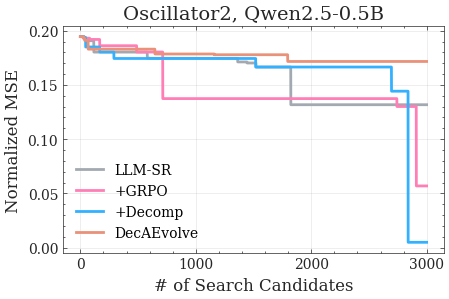

In [11]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "oscillator2_llmsr_Qwen2.5-0.5B-Instruct",
    "oscillator2_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75",
    "oscillator2_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
    "oscillator2_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75_v2",
]

# modified
# log_ids = [
#     "oscillator2_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75_v2",
#     "oscillator2_llmsr_Qwen2.5-0.5B-Instruct",
#     "oscillator2_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
#     "oscillator2_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))


import pandas as pd
data_path = f'./data/oscillator2/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.7, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        
        # if i == 2 or i == 0:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                    label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("Oscillator2, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
# plt.yscale('log')  # Set y-axis to log scale
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2000)
plt.xticks(np.arange(0, 3001, 1000))
from matplotlib.ticker import MaxNLocator
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_oscillator2-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen-1.5B

0 5.496512227662594e-10
1 6.084176536572784e-10
2 1.895008581581455e-12
3 5.039379539864272e-05


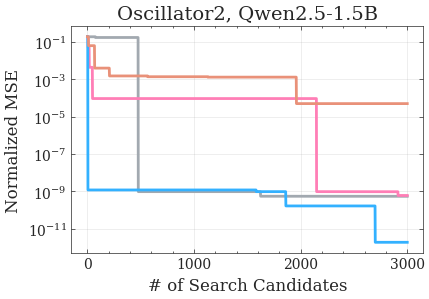

In [12]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None


log_ids = [
    "oscillator2_llmsr_Qwen2.5-1.5B-Instruct",
    "oscillator2_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
    "oscillator2_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "oscillator2_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
]

# modified
# log_ids = [
#     "oscillator2_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "oscillator2_llmsr_Qwen2.5-1.5B-Instruct",
#     "oscillator2_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "oscillator2_llmsr_dec_Qwen2.5-1.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/oscillator2/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        
        # if i == 3 or i == 0:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("Oscillator2, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_oscillator2-qwen-15b_v2.pdf', dpi=300, bbox_inches='tight')

## BactGrow

### Qwen2.5-0.5B

0 0.5835863796958937
1 0.760238704574411
2 0.7290593304675996
3 0.7860057668434195


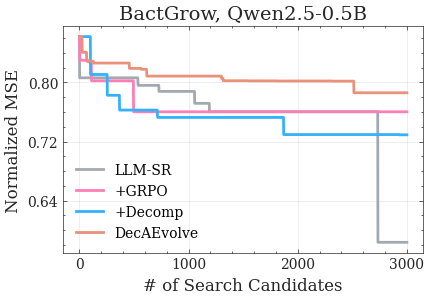

In [15]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "bactgrow_llmsr_Qwen2.5-0.5B-Instruct",
    "bactgrow_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
    "bactgrow_llmsr_dec_Qwen2.5-0.5B-Instruct",
    "bactgrow_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
]

# modified
# log_ids = [
#     "bactgrow_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
#     "bactgrow_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
#     "bactgrow_llmsr_Qwen2.5-0.5B-Instruct",
#     "bactgrow_llmsr_dec_Qwen2.5-0.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/bactgrow/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        # if i == 2:
            # Compute the change in nmse between index 2000 and 300
            # Find the index between 2500 and 3000 where the largest change in nmse occurs
            # if len(nmse) > 2000:
            #     search_start = 2500
            #     search_end = 3000
            #     nmse_segment = nmse[search_start:search_end]
            #     diffs = np.abs(np.diff(nmse_segment))
            #     max_change_idx = np.argmax(diffs) + search_start
            #     print(f"Largest change in nmse between 2500 and 3000 at index {max_change_idx}: Δ={nmse[max_change_idx+1] - nmse[max_change_idx]}")
            
        #     idx = 2732
        #     if len(nmse) >= idx and len(nmse) <= 3000:
        #         nmse_change = nmse[idx-1] - nmse[2999]
        #         print(nmse_change)
        #         nmse[idx+1:] = nmse[idx+1:] + nmse_change 
        #     plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("BactGrow, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
# plt.yscale('log')  # Set y-axis to log scale
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))
from matplotlib.ticker import MaxNLocator
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))



# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_bactgrow-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen2.5-1.5B

0 0.6410789162041821
1 0.4826650296810399
2 0.6860073082860568
3 0.3156459005754748


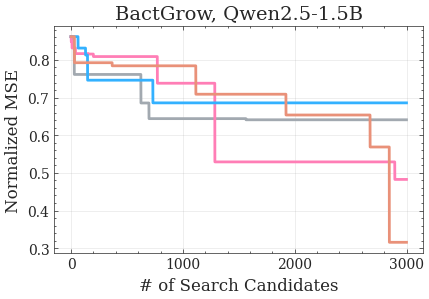

In [16]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None


log_ids = [
    "bactgrow_llmsr_Qwen2.5-1.5B-Instruct",
    "bactgrow_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
    "bactgrow_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "bactgrow_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
]


# modified
# log_ids = [
#     "bactgrow_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
#     "bactgrow_llmsr_Qwen2.5-1.5B-Instruct",
#     "bactgrow_llmsr_dec_Qwen2.5-1.5B-Instruct",
#     "bactgrow_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
    
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/bactgrow/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        # if i == 2 or i == 0:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
            label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("BactGrow, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
# plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_bactgrow-qwen-15b_v2.pdf', dpi=300, bbox_inches='tight')

## StressStrain

### Qwen2.5-0.5B

0 0.08913410647900885
1 0.23621084051127847
2 0.15057501958722808
3 0.20756302390046646


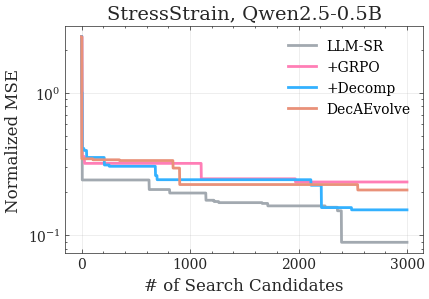

In [17]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None


log_ids = [
    "stressstrain_llmsr_Qwen2.5-0.5B-Instruct",
    "stressstrain_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125",
    "stressstrain_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
    "stressstrain_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125_v2",
]

# modified
# log_ids = [
#     "stressstrain_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125",
#     "stressstrain_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
#     "stressstrain_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125_v2",
#     "stressstrain_llmsr_Qwen2.5-0.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/stressstrain/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("StressStrain, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_stressstrain-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen2.5-1.5B

0 0.026717558598583522
1 0.05478931936625529
2 0.026436117757580712
3 0.08071355882719158


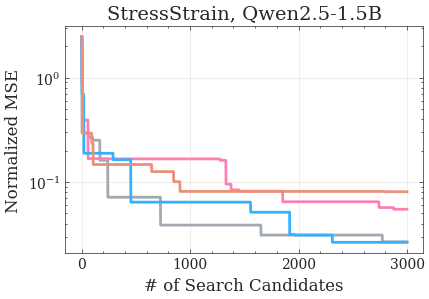

In [18]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "stressstrain_llmsr_Qwen2.5-1.5B-Instruct",
    "stressstrain_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
    "stressstrain_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "stressstrain_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
]

# modified
# log_ids = [
#     "stressstrain_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "stressstrain_llmsr_dec_Qwen2.5-1.5B-Instruct",
#     "stressstrain_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "stressstrain_llmsr_Qwen2.5-1.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/stressstrain/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("StressStrain, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_stressstrain-qwen-15b_v2.pdf', dpi=300, bbox_inches='tight')

## ID - OOD Comparison (All Datasets)

### Qwen-0.5B

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def create_comparison_barplot():
    # Fix: Ensure all arrays in DataFrame are of the same length (8 for 2 domains x 4 methods)
    id_means = pd.DataFrame({
        'domain': [
            'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B',
            'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B',
        ],
        'method': [
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
        ],
        #Oscillator1
        'median_nmse': [
            0.0020535036321787845, 0.0022578616001351784, 0.003234122088762386, 2.8515104559452787e-06,   # Oscillator1
            1.8955334870212296e-05, 1.3547777632424706e-10, 8.69622652861603e-07, 1.476429221349961e-10,   # Oscillator1
        ]
        # # #Oscillator2
        # 'median_nmse': [
        #     0.1716241439486218, 0.13175753031363, 0.164957014217872659, 0.06,   # Oscillator2
        #     5.039379539864272e-05, 5.496512227662594e-10, 6.084176536572784e-10, 1.6774734546603405e-10,   # Oscillator2
        # ]
        # #BactGrow
        # 'median_nmse': [
        #     0.7860057668434195, 0.760238704574411, 0.7603671026887362, 0.7290593304675996,   # BactGrow
        #     0.6537859119358005, 0.6410789162041821, 0.6860073082860568, 0.4826650296810399,   # BactGrow
        # ]
        # # #StressStrain
        # 'median_nmse': [
        #     0.23621084051127847, 0.15057501958722808, 0.20756302390046646, 0.08913410647900885,    # StressStrain
        #     0.05478931936625529, 0.026436117757580712, 0.08071355882719158, 0.026717558598583522,   # StressStrain
        # ]

    })

    ood_means = pd.DataFrame({
        'domain': [
            'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B',
            'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B',
        ],
        'method': [
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
        ],
        # 'median_ood_nmse': [
        #     0.012, 0.008, 0.007, 2.82e-05,   # Qwen2.5-0.5B
        #     5.2e-03, 1.4e-6, 3.6e-06, 5.4e-8,   # Qwen2.5-1.5B
        # ]
        #Oscillator2
        'median_ood_nmse': [
            # 0.221, 0.138, 0.155, 0.065,   # Oscillator2
            # 2.03e-02, 5.4e-4, 6.08e-3, 1.67e-6,   # 
            0.012, 0.008, 0.007, 2.82e-05,   # Oscillator1
            5.2e-03, 1.4e-6, 3.6e-06, 5.4e-8, 
            # 0.801, 0.775, 0.764, 0.731,   # BactGrow
            # 0.78, 0.68, 0.72, 0.52,  
            # 0.28, 0.21, 0.22, 0.11,   # StressStrain
            # 0.15478931936625529, 0.126436117757580712, 0.18071355882719158, 0.04, 
        ]
    })

    domains = ["Qwen2.5-0.5B", "Qwen2.5-1.5B"]

    fig, ax = plt.subplots(figsize=(8, 4))

    n_domains = len(domains)
    methods = model_variants
    n_methods = len(methods)

    # Calculate bar positions with adjusted spacing
    bar_width = 0.3
    domain_padding = 1.2  # Large padding between domains
    id_ood_padding = 0.3  # Moderate padding between ID and OOD groups

    # Calculate the total width needed for all bars in a domain group
    group_width = (n_methods * bar_width * 2) + id_ood_padding  # Width for both ID and OOD groups plus padding

    # Create positions for each domain
    domain_positions = np.arange(n_domains) * (group_width + domain_padding)

    # Create legend elements
    method_patches = []
    for i, method in enumerate(methods):
        color = colors[i]
        method_patches.append(Patch(facecolor=carbon[color]["40"], alpha=0.8, label=method))

    distribution_patches = [
        Patch(facecolor='none', alpha=0.8, edgecolor='black', label='ID'),
        Patch(facecolor='none', alpha=0.8, edgecolor='black', hatch='//', label='OOD')
    ]

    # # Plot bars
    # for i, method in enumerate(methods):
    #     # ID bars - grouped together
    #     id_data = id_means[id_means['method'] == method]
    #     pos_id = domain_positions + (i * bar_width)
    #     color = colors[i]
    #     ax.bar(pos_id,
    #            id_data['median_nmse'],
    #            bar_width,
    #            color=carbon[color]["40"],
    #            alpha=0.7,
    #            edgecolor='black',
    #            linewidth=1,)

    #     # OOD bars - grouped together with padding
    #     ood_data = ood_means[ood_means['method'] == method]
    #     pos_ood = domain_positions + (n_methods * bar_width) + id_ood_padding + (i * bar_width)
    #     color = colors[i]
    #     ax.bar(pos_ood,
    #            ood_data['median_ood_nmse'],
    #            bar_width,
    #            color=carbon[color]["40"],
    #            alpha=0.5,
    #            edgecolor='black',
    #            linewidth=1,
    #            hatch='//')

    ax.grid(axis='x', color=carbon['gray']['40'], lw=0.2)
    ax.grid(axis='y', color=carbon['gray']['40'], lw=0.2)
    ax.set_ylabel(r'Normalized MSE', fontsize=14)

    domain_labels = ["Qwen2.5-0.5B", "Qwen2.5-1.5B"]

    ax.set_xticks(domain_positions + group_width/2)
    ax.set_xticklabels(domain_labels, fontsize=8, ha='center')
    ax.tick_params(axis='x', which='major', pad=8)  # Adds some padding below the labels

    # Also increase y-axis tick label size if desired
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Set y-axis to log scale
    ax.set_yscale('log')
    ax.set_title('Oscillator1', fontsize=14)
    # To set custom y-ticks, use ax.set_yticks() and optionally ax.set_yticklabels()
    # Example: set y-ticks at [0.01, 0.1, 1, 10, 100] for log scale
    # ax.set_yticks([0.01, 0.1, ])
    # ax.set_yticklabels([r'$10^{-2}$', r'$10^{-1}$',])

    # Create two separate legends
    # Methods legend (colors)
    first_legend = ax.legend(ncol=4,
                        handles=method_patches, 
                        #    bbox_to_anchor=(1.01, 0.98),
                           bbox_to_anchor=(-0.05, -0.18),
                           loc='upper left',
                           borderaxespad=0.,
                           frameon=True,)

    # Add the first legend manually
    ax.add_artist(first_legend)

    # Distribution legend (patterns)
    ax.legend(ncol=2,
             handles=distribution_patches,
             bbox_to_anchor=(0.755, -0.18),  # Centered below the figure
             loc='upper left',
             borderaxespad=0.,
             frameon=True,)

    # ax.spines['top'].set_linewidth(2)
    # ax.spines['top'].set_visible(False)
    # ax.spines['bottom'].set_linewidth(1)
    # ax.spines['left'].set_linewidth(1)
    # ax.spines['right'].set_visible(False)

    # from matplotlib.ticker import MaxNLocator
    # ax = plt.gca()
    # ax.yaxis.set_major_locator(MaxNLocator(nbins=10))
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.savefig('./figs/oscillator1_nmse_id_ood_v3.png', dpi=600, bbox_inches='tight', pad_inches=0.6)
    return fig

colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]
model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]
create_comparison_barplot()


## GRPO Rewards

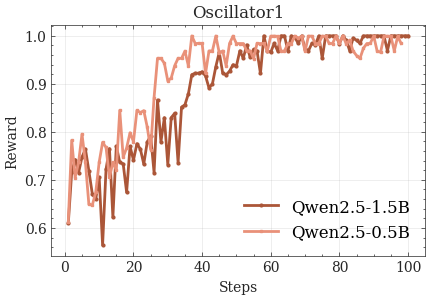

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove any seaborn style that may be set globally
# plt.style.use('default')

# Read the CSV file
df = pd.read_csv('rewards/osc1_rewards.csv')
# df = pd.read_csv('rewards/osc2_rewards.csv')
# df = pd.read_csv('rewards/bg_rewards.csv')
# df = pd.read_csv('rewards/ss_rewards.csv')

# Only plot up to step 100
df = df[df['train/global_step'] <= 100]

# Set up the plot
import matplotlib

matplotlib.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize=(4.5, 3.2))

# Plot rewards for both models
# Model 1: Qwen2.5-1.5B
ax.plot(df['train/global_step'], 
        df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756158958 - train/reward'], #Osc1
        # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756174399 - train/reward'],  #Osc2
        # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756182413 - train/reward'],  #BactGrow
        # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756184995 - train/reward'],  #StressStrain
        color=carbon['rose']['60'],
        label='Qwen2.5-1.5B', linewidth=2, marker='o', markersize=2)

# Model 2: Qwen2.5-0.5B (only plot up to where data exists)
mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1755898769 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756174705 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756181910 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756185192 - train/reward'].notna()
ax.plot(df.loc[mask_0_5b, 'train/global_step'], 
        df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1755898769 - train/reward'], #Osc1
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756174705 - train/reward'], #Osc2
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756181910 - train/reward'], #Bactgrow
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756185192 - train/reward'], #StressStrain
        color=carbon['rose']['40'],
        label='Qwen2.5-0.5B', linewidth=2, marker='s', markersize=2)

# Customize the plot
ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
# ax.set_title('Oscillator2')
# ax.set_title('Bactgrow')
# ax.set_title('Stressstrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)


# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

# Add some styling
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Adjust layout and display
plt.tight_layout()

# Save the plot in the ./figs/ directory
plt.savefig('./figs/osc1-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/osc2-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/bactgrow-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/stressstrain-rewards.pdf', dpi=300, bbox_inches='tight')
plt.show()


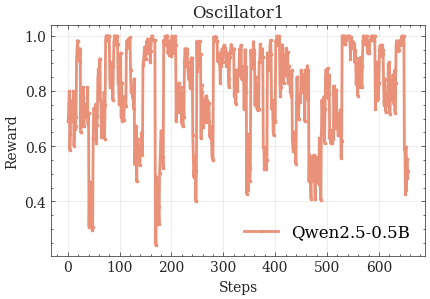

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove any seaborn style that may be set globally
# plt.style.use('default')

# Read the CSV file
# df = pd.read_csv('rewards/osc1_adaptive_qwen05_steps8_temp09_rewards.csv')
df = pd.read_csv('rewards/osc1_adaptive_qwen05_steps8_temp01_rewards.csv')
# df = pd.read_csv('rewards/osc2_rewards.csv')
# df = pd.read_csv('rewards/bg_rewards.csv')
# df = pd.read_csv('rewards/ss_rewards.csv')

# Only plot up to step 100
# df = df[df['train/global_step'] <= 100]

# Set up the plot
import matplotlib

matplotlib.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize=(4.5, 3.2))

# Plot rewards for both models
# Model 1: Qwen2.5-1.5B
# ax.plot(df['train/global_step'], 
#         df['episode-0-Qwen/Qwen2.5-0.5B-Instruct-r8-ga8-ng64-1757625780315 - train/reward'], #Osc1
#         # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756174399 - train/reward'],  #Osc2
#         # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756182413 - train/reward'],  #BactGrow
#         # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756184995 - train/reward'],  #StressStrain
#         color=carbon['rose']['60'],
#         label='Qwen2.5-1.5B', linewidth=2, marker='o', markersize=2)

# Model 2: Qwen2.5-0.5B (only plot up to where data exists)

# mask_0_5b = df['episode-0-Qwen/Qwen2.5-0.5B-Instruct-r8-ga8-ng64-1757625780315 - train/reward'].notna()
mask_0_5b = df['episode-0-Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1757605758572 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756174705 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756181910 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756185192 - train/reward'].notna()
ax.plot(df.loc[mask_0_5b, 'train/global_step'], 
        # df.loc[mask_0_5b, 'episode-0-Qwen/Qwen2.5-0.5B-Instruct-r8-ga8-ng64-1757625780315 - train/reward'], #Osc1
        df.loc[mask_0_5b, 'episode-0-Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1757605758572 - train/reward'], #Osc1
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756174705 - train/reward'], #Osc2
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756181910 - train/reward'], #Bactgrow
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756185192 - train/reward'], #StressStrain
        color=carbon['rose']['40'],
        label='Qwen2.5-0.5B', linewidth=2, marker='s', markersize=2)

# Customize the plot
ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
# ax.set_title('Oscillator2')
# ax.set_title('Bactgrow')
# ax.set_title('Stressstrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)


# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

# Add some styling
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Adjust layout and display
plt.tight_layout()

# Save the plot in the ./figs/ directory
# plt.savefig('./figs/osc1_adaptive_qwen05_steps8_temp09_rewards.pdf', dpi=300, bbox_inches='tight')
plt.savefig('./figs/osc1_adaptive_qwen05_steps8_temp01_rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/osc2-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/bactgrow-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/stressstrain-rewards.pdf', dpi=300, bbox_inches='tight')
plt.show()
